## Cost functions with regularization
### Cost function for regularized linear regression
The equation for the cost function of regularized linear regression is:

$$J(\mathbf{w},b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})^2  + \frac{\lambda}{2m}  \sum_{j=0}^{n-1} w_j^2$$
*(1)*

where:

$$f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = \mathbf{w} \cdot \mathbf{x}^{(i)} + b$$
*(2)*

Compare this to the cost function without regularization:

$$J(\mathbf{w},b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})^2$$

The difference is the regularization term, $\frac{\lambda}{2m}  \sum_{j=0}^{n-1} w_j^2$.

Including this term encourages gradient descent to minimize the size of the parameters. Note, in this example, the parameter $b$ is not regularized — this is standard practice.

Below is an implementation of equations (1) and (2), using the same `for loop` pattern over all `m` examples used throughout this course.

**Reading the code against the formula** — the first block (`cost = ...`) is exactly your existing `compute_cost` from earlier in this conversation, unchanged: loop over `i`, accumulate squared error, divide by `2m`.

The second block (`reg_cost = ...`) is new — a **separate loop over `j` (features, not examples)**, summing $w_j^2$ for every feature, then scaling by $\frac{\lambda}{2m}$. This is a different loop variable and a different range (`n` features, not `m` examples) — worth noting since it's easy to accidentally conflate the two loops.

`total_cost = cost + reg_cost` combines both terms — matching equation (1) directly: unregularized cost plus the regularization term, added once at the very end.

In [8]:
def compute_cost_linear_reg(X, y, w, b, lambda_ = 1):
    """
    Computes the cost over all examples
    Args:
      X (ndarray (m,n): Data, m examples with n features
      y (ndarray (m,)): target values
      w (ndarray (n,)): model parameters  
      b (scalar)      : model parameter
      lambda_ (scalar): Controls amount of regularization
    Returns:
      total_cost (scalar):  cost 
    """
    m  = X.shape[0]
    n  = len(w)
    cost = 0.
    for i in range(m):
        f_wb_i = np.dot(X[i], w) + b                                   #(n,)(n,)=scalar, see np.dot
        cost = cost + (f_wb_i - y[i])**2                               #scalar             
    cost = cost / (2 * m)                                              #scalar  
 
    reg_cost = 0
    for j in range(n):
        reg_cost += (w[j]**2)                                          #scalar
    reg_cost = (lambda_/(2*m)) * reg_cost                              #scalar
    
    total_cost = cost + reg_cost                                       #scalar
    return total_cost                                                  #scalar

### Cost function for regularized logistic regression
For regularized **logistic** regression, the cost function is of the form:

$$J(\mathbf{w},b) = \frac{1}{m}  \sum_{i=0}^{m-1} \left[ -y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) \right] + \frac{\lambda}{2m}  \sum_{j=0}^{n-1} w_j^2$$
*(3)*

where:

$$f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = sigmoid(\mathbf{w} \cdot \mathbf{x}^{(i)} + b)$$
*(4)*

Compare this to the unregularized cost function:

$$J(\mathbf{w},b) = \frac{1}{m}\sum_{i=0}^{m-1} \left[ -y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right)\right]$$

As with linear regression above, the difference is the same regularization term, $\frac{\lambda}{2m}  \sum_{j=0}^{n-1} w_j^2$ — and $b$ remains unregularized, same standard practice.

**Same pattern as linear regression's regularized cost** — the base cost loop is identical to your earlier `compute_cost_logistic` (sigmoid + combined log-loss formula), and the exact same `reg_cost` block from `compute_cost_linear_reg` is appended afterward, unchanged. Regularization is added as a separate, self-contained term on top of whichever base cost function you're using — that modularity is worth noticing, since it's the same pattern you'll see again in the gradient functions next.

In [9]:
def compute_cost_logistic_reg(X, y, w, b, lambda_ = 1):
    """
    Computes the cost over all examples
    Args:
      X (ndarray (m,n): Data, m examples with n features
      y (ndarray (m,)): target values
      w (ndarray (n,)): model parameters  
      b (scalar)      : model parameter
      lambda_ (scalar): Controls amount of regularization
    Returns:
      total_cost (scalar):  cost 
    """
    m,n  = X.shape
    cost = 0.
    for i in range(m):
        z_i = np.dot(X[i], w) + b                                      #(n,)(n,)=scalar, see np.dot
        f_wb_i = sigmoid(z_i)                                          #scalar
        cost +=  -y[i]*np.log(f_wb_i) - (1-y[i])*np.log(1-f_wb_i)      #scalar
             
    cost = cost/m                                                      #scalar
    reg_cost = 0
    for j in range(n):
        reg_cost += (w[j]**2)                                          #scalar
    reg_cost = (lambda_/(2*m)) * reg_cost                              #scalar
    
    total_cost = cost + reg_cost                                       #scalar
    return total_cost                                                  #scalar

### Computing the Gradient with regularization (both linear/logistic)
The gradient calculation for both linear and logistic regression are nearly identical, differing only in how $f_{\mathbf{w},b}$ is computed:

$$\begin{align*}
\frac{\partial J(\mathbf{w},b)}{\partial w_j}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})x_{j}^{(i)}  +  \frac{\lambda}{m} w_j \\
\frac{\partial J(\mathbf{w},b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})
\end{align*}$$
*(2), (3)*

* $m$ is the number of training examples in the data set      
* $f_{\mathbf{w},b}(x^{(i)})$ is the model's prediction, $y^{(i)}$ is the target
* For **linear** regression: $f_{\mathbf{w},b}(x) = \mathbf{w} \cdot \mathbf{x} + b$
* For **logistic** regression: $z = \mathbf{w} \cdot \mathbf{x} + b$, $f_{\mathbf{w},b}(x) = g(z)$, where $g(z) = \frac{1}{1+e^{-z}}$

Notice $\frac{\partial J}{\partial b}$ has **no regularization term** — this matches "b is not regularized" from the cost function definitions above; only the $w_j$ gradient gets the extra $\frac{\lambda}{m}w_j$ term.

**Reading the structure** — the first two loops (accumulating `err`, then dividing by `m`) are exactly your original `compute_gradient` from earlier in this conversation, completely unchanged. Regularization is added as a **third, separate loop afterward** — looping over `j` (features) and adding $\frac{\lambda}{m}w_j$ onto each `dj_dw[j]` individually.

Note this term is added **after** `dj_dw = dj_dw / m` — the accumulated sum is already averaged by that point, and $\frac{\lambda}{m}w_j$ gets added directly (not accumulated/summed like the loss term was), since it only depends on a single `w[j]`, not a sum over examples.

In [10]:
def compute_gradient_linear_reg(X, y, w, b, lambda_): 
    """
    Computes the gradient for linear regression 
    Args:
      X (ndarray (m,n): Data, m examples with n features
      y (ndarray (m,)): target values
      w (ndarray (n,)): model parameters  
      b (scalar)      : model parameter
      lambda_ (scalar): Controls amount of regularization
      
    Returns:
      dj_dw (ndarray (n,)): The gradient of the cost w.r.t. the parameters w. 
      dj_db (scalar):       The gradient of the cost w.r.t. the parameter b. 
    """
    m,n = X.shape           #(number of examples, number of features)
    dj_dw = np.zeros((n,))
    dj_db = 0.
    for i in range(m):                             
        err = (np.dot(X[i], w) + b) - y[i]                 
        for j in range(n):                         
            dj_dw[j] = dj_dw[j] + err * X[i, j]               
        dj_db = dj_db + err                        
    dj_dw = dj_dw / m                                
    dj_db = dj_db / m   
    
    for j in range(n):
        dj_dw[j] = dj_dw[j] + (lambda_/m) * w[j]
    return dj_db, dj_dw

**Same regularization addition, applied to the logistic gradient** — compare directly against Chunk 6: the base two-loop structure differs only in `f_wb_i = sigmoid(...)` replacing the raw linear combination, exactly matching the "differing only in computation of $f_{\mathbf{w},b}$" note from the math above. The regularization loop appended at the end is character-for-character identical between both functions — same `for j in range(n): dj_dw[j] = dj_dw[j] + (lambda_/m) * w[j]` block in both.

In [11]:
def compute_gradient_logistic_reg(X, y, w, b, lambda_): 
    """
    Computes the gradient for logistic regression 
 
    Args:
      X (ndarray (m,n): Data, m examples with n features
      y (ndarray (m,)): target values
      w (ndarray (n,)): model parameters  
      b (scalar)      : model parameter
      lambda_ (scalar): Controls amount of regularization
    Returns
      dj_dw (ndarray Shape (n,)): The gradient of the cost w.r.t. the parameters w. 
      dj_db (scalar)            : The gradient of the cost w.r.t. the parameter b. 
    """
    m,n = X.shape
    dj_dw = np.zeros((n,))                            #(n,)
    dj_db = 0.0                                       #scalar
    for i in range(m):
        f_wb_i = sigmoid(np.dot(X[i],w) + b)          #(n,)(n,)=scalar
        err_i  = f_wb_i  - y[i]                       #scalar
        for j in range(n):
            dj_dw[j] = dj_dw[j] + err_i * X[i,j]      #scalar
        dj_db = dj_db + err_i
    dj_dw = dj_dw/m                                   #(n,)
    dj_db = dj_db/m                                   #scalar
    for j in range(n):
        dj_dw[j] = dj_dw[j] + (lambda_/m) * w[j]
    return dj_db, dj_dw

Using the Breast Cancer dataset again for consistency with your earlier logistic regression chunks. This reuses the `gradient_descent` driver function from before — unchanged — just passing it the regularized gradient/cost functions instead.

In [14]:
import numpy as np
import copy
import math
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def gradient_descent_reg(X, y, w_in, b_in, alpha, num_iters, lambda_, cost_function, gradient_function):
    J_history = []
    w = copy.deepcopy(w_in)
    b = b_in
    for i in range(num_iters):
        dj_db, dj_dw = gradient_function(X, y, w, b, lambda_)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        if i < 100000:
            J_history.append(cost_function(X, y, w, b, lambda_))
        if i % math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i:4d}: Cost {J_history[-1]:.4f}")
    return w, b, J_history

n_features = X_train_scaled.shape[1]
w_init = np.zeros(n_features)
b_init = 0.0

# train with two different lambda values to compare
w_lo, b_lo, J_hist_lo = gradient_descent_reg(X_train_scaled, y_train, w_init, b_init, alpha=0.1, num_iters=1000, lambda_=0.01, cost_function=compute_cost_logistic_reg, gradient_function=compute_gradient_logistic_reg)
w_hi, b_hi, J_hist_hi = gradient_descent_reg(X_train_scaled, y_train, w_init, b_init, alpha=0.1, num_iters=1000, lambda_=50, cost_function=compute_cost_logistic_reg, gradient_function=compute_gradient_logistic_reg)

Iteration    0: Cost 0.5164
Iteration  100: Cost 0.1002
Iteration  200: Cost 0.0830
Iteration  300: Cost 0.0754
Iteration  400: Cost 0.0709
Iteration  500: Cost 0.0678
Iteration  600: Cost 0.0655
Iteration  700: Cost 0.0637
Iteration  800: Cost 0.0623
Iteration  900: Cost 0.0610
Iteration    0: Cost 0.5176
Iteration  100: Cost 0.2002
Iteration  200: Cost 0.1984
Iteration  300: Cost 0.1980
Iteration  400: Cost 0.1979
Iteration  500: Cost 0.1979
Iteration  600: Cost 0.1979
Iteration  700: Cost 0.1979
Iteration  800: Cost 0.1979
Iteration  900: Cost 0.1979


Same convergence-check plot as before, now overlaying two `lambda_` values on one chart, to see how regularization strength affects the cost curve's shape/level.

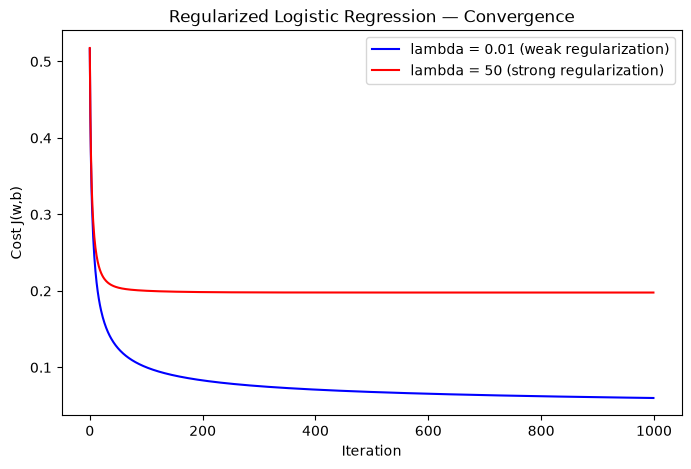

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(J_hist_lo, color='blue', label='lambda = 0.01 (weak regularization)')
plt.plot(J_hist_hi, color='red', label='lambda = 50 (strong regularization)')
plt.xlabel('Iteration')
plt.ylabel('Cost J(w,b)')
plt.title('Regularized Logistic Regression — Convergence')
plt.legend()
plt.show()

**This is the plot that directly visualizes what regularization is supposed to do** — "encourages gradient descent to minimize the size of the parameters," from the math notes above. Comparing `w` magnitudes between low and high `lambda_` should show the high-lambda bars shrunk toward zero relative to low-lambda.

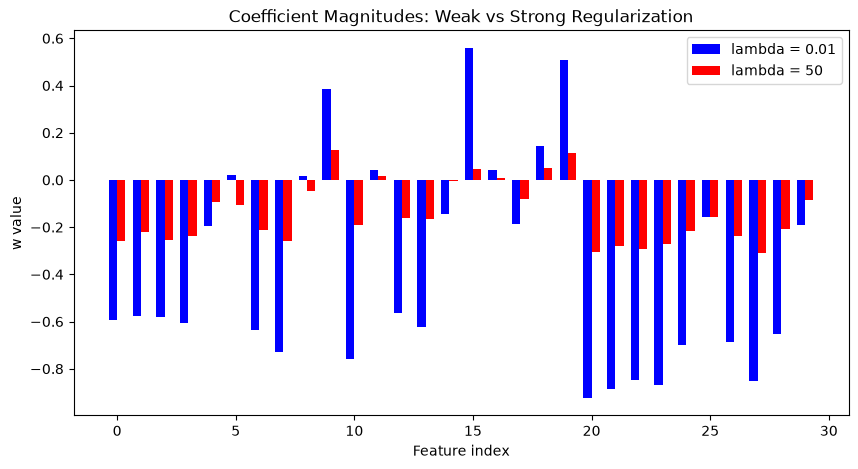

In [16]:
x_pos = np.arange(len(w_lo))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x_pos - width/2, w_lo, width, color='blue', label='lambda = 0.01')
plt.bar(x_pos + width/2, w_hi, width, color='red', label='lambda = 50')
plt.xlabel('Feature index')
plt.ylabel('w value')
plt.title('Coefficient Magnitudes: Weak vs Strong Regularization')
plt.legend()
plt.show()